In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/india_city_aqi_2015_2023-original_dataset.csv")

In [3]:
df.head(11)

,city,date,pm2.5,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,01-01-2015,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,02-01-2015,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,03-01-2015,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,04-01-2015,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,05-01-2015,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory
5,Delhi,06-01-2015,55.931736,142.977299,39.797542,6.711445,1.046763,31.687345,78,Satisfactory
6,Delhi,07-01-2015,88.354544,99.161141,20.077209,12.984306,1.021540,52.570524,81,Satisfactory
7,Delhi,08-01-2015,75.374069,119.351995,17.822170,8.400779,0.661808,65.856833,81,Satisfactory
8,Delhi,09-01-2015,93.744732,108.483929,44.861260,10.074589,0.596923,59.175144,89,Satisfactory
9,Delhi,10-01-2015,121.239981,189.865583,27.411737,10.453938,0.899379,64.633177,126,Moderate


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          32870 non-null  object 
 1   date          32870 non-null  object 
 2   pm2.5         32870 non-null  float64
 3   pm10          32870 non-null  float64
 4   no2           32870 non-null  float64
 5   so2           32870 non-null  float64
 6   co            32870 non-null  float64
 7   o3            32870 non-null  float64
 8   aqi           32870 non-null  int64  
 9   aqi_category  32870 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.5+ MB


In [5]:
df.describe()

,pm2.5,pm10,no2,so2,co,o3,aqi
count,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000
mean,80.757235,130.764579,40.165472,11.998476,0.802118,49.979732,88.122665
std,39.063392,43.937066,14.849411,4.882239,0.298156,14.912687,31.895407
min,5.000000,10.000000,5.000000,2.000000,0.100000,10.000000,11.000000
25%,53.154180,99.980177,29.990183,8.570939,0.599976,39.892800,65.000000
50%,80.336105,130.023453,40.141525,11.977979,0.800137,49.977582,88.000000
75%,107.496909,160.634804,50.190860,15.315028,1.003899,60.025440,110.000000
max,248.081036,330.014171,97.446733,34.395421,1.929870,118.431721,221.000000


In [6]:
df.isna().sum()

city            0
date            0
pm2.5           0
pm10            0
no2             0
so2             0
co              0
o3              0
aqi             0
aqi_category    0
dtype: int64

In [7]:
initial_count = len(df)

df['pm2.5/pm10 ratio'] = df['pm2.5'] / df['pm10']

mask = (df['pm2.5/pm10 ratio'] >= 0.15) & (df['pm2.5/pm10 ratio'] <= 1.0)
df_cleaned = df[mask].copy()

final_count = len(df_cleaned)
removed_count = initial_count - final_count

df_cleaned = df_cleaned.drop(columns=['pm2.5/pm10 ratio'])
df_cleaned.to_csv("../data/india_city_aqi_2015_2023-cleaned_dataset.csv", index=False)

print("Processing Complete:")
print("- Original records: ",initial_count)
print("- Records removed: ",removed_count)
print("- Final records: ",final_count)
print("- File saved as: '../data/india_city_aqi_2015_2023-cleaned_dataset.csv' ")

Processing Complete:
- Original records:  32870
- Records removed:  1357
- Final records:  31513
- File saved as: '../data/india_city_aqi_2015_2023-cleaned_dataset.csv' 


In [8]:
# Distribution Analysis
pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']
dist_stats = df[pollutants].agg(['skew', 'kurtosis']).transpose()
print("--- DISTRIBUTION METRICS ---")
print(dist_stats)

--- DISTRIBUTION METRICS ---
           skew  kurtosis
pm2.5  0.152167 -0.310323
pm10   0.121947 -0.206534
no2    0.065520 -0.163814
so2    0.121223 -0.255383
co     0.056139 -0.150230
o3     0.013469 -0.099970


<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\MUKUND PRASAD\AppData\Local\Temp\ipykernel_35592\2120425454.py:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  unit = "$\mu g/m^3$"


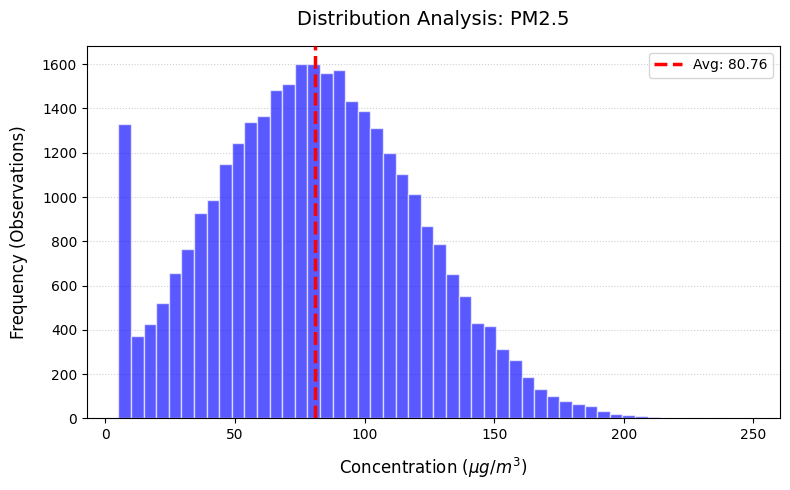

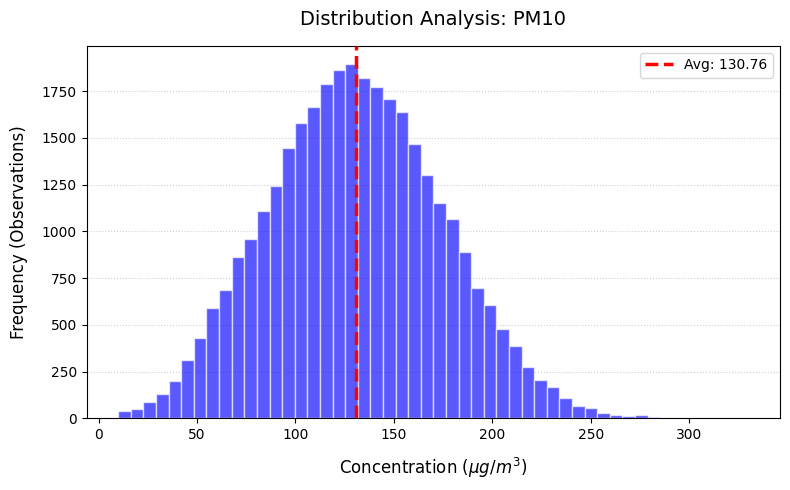

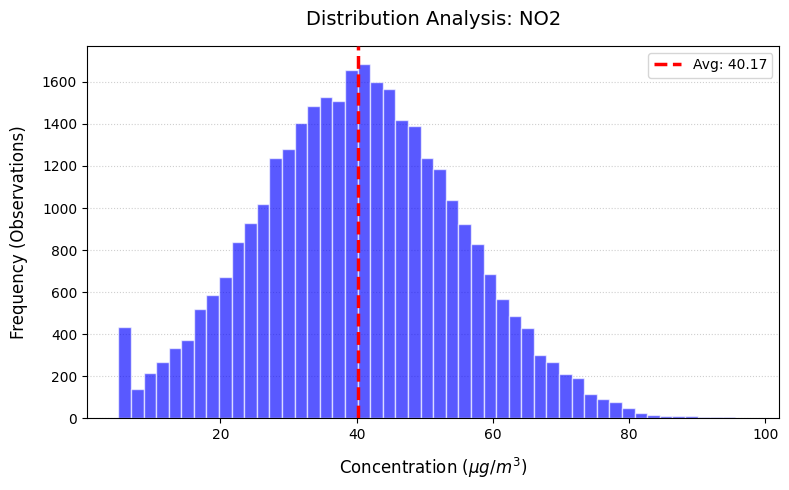

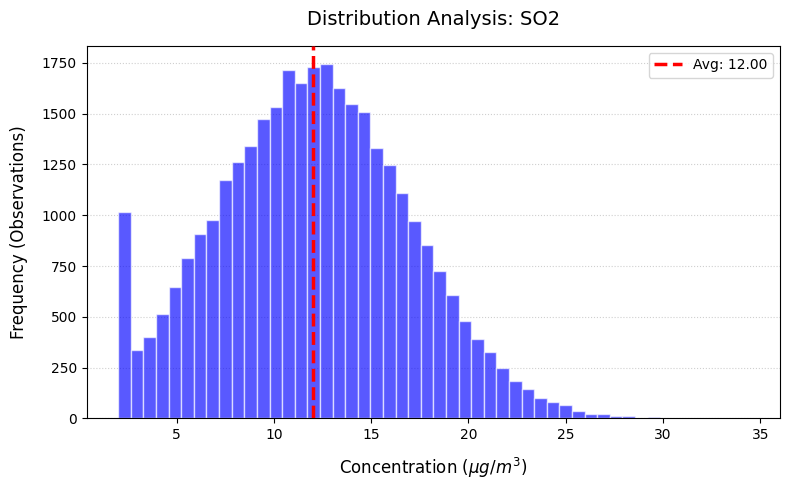

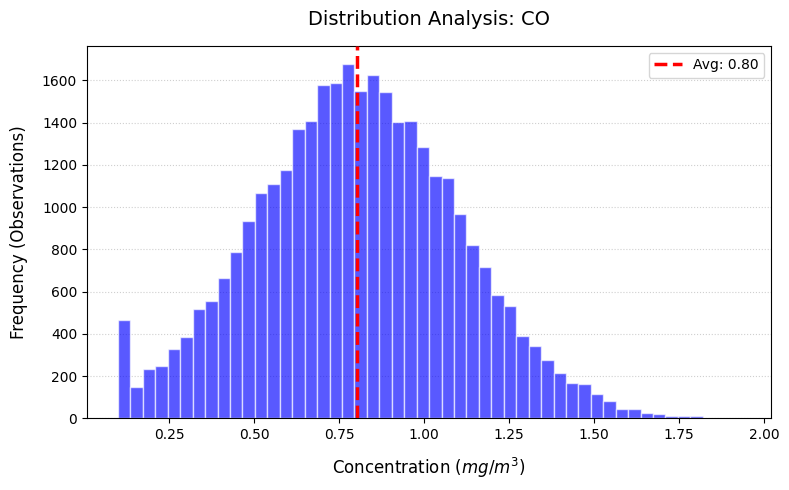

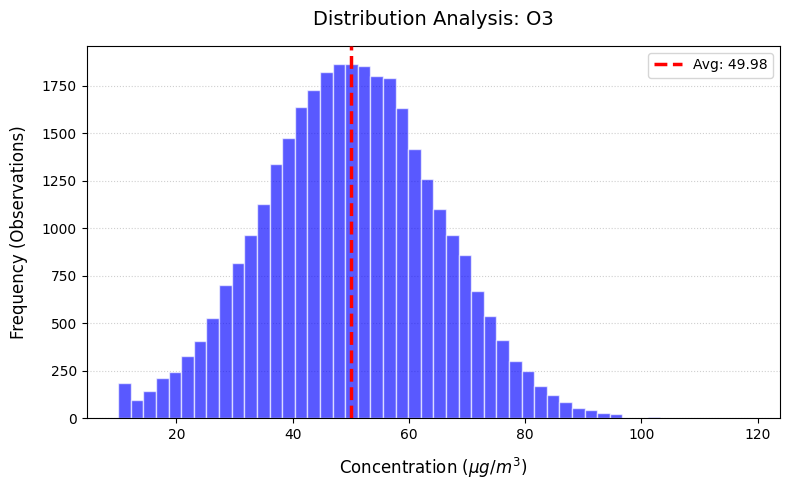

In [9]:
pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']

for pollutant in pollutants:
    plt.figure(figsize=(8, 5))
    if pollutant.lower() == 'co':
        unit = "$mg/m^3$"
    else:
        unit = "$\mu g/m^3$"
        
    avg_val = df[pollutant].mean()
    plt.hist(df[pollutant].dropna(), bins=50, color='blue', edgecolor='white', alpha=0.65, zorder=2)
    
    plt.axvline(avg_val, color='red', linestyle='--', linewidth=2.5, label=f'Avg: {avg_val:.2f}', zorder=3)
    # 5. Formatting with Units
    plt.title(f'Distribution Analysis: {pollutant.upper()}', fontsize=14, pad=15)
    plt.xlabel(f'Concentration ({unit})', fontsize=12, labelpad=10)
    plt.ylabel('Frequency (Observations)', fontsize=12, labelpad=10)
    
    plt.legend(frameon=True, loc='upper right')
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=1)
    
    plt.tight_layout()
    plt.show()

In [10]:
df['aqi_adj'] = df['aqi'].round(0)
bins = [-np.inf, 50, 100, 200, np.inf]
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor']

df['aqi_category'] = pd.cut(df['aqi_adj'], bins=bins, labels=labels)

print("--- AQI Value Ranges (With Floating Adjustments) ---")
category_check = df.groupby('aqi_category', observed=False)['aqi'].agg(['min', 'max', 'count'])

print(category_check)

# Clean up temporary column
df = df.drop(columns=['aqi_adj'])

--- AQI Value Ranges (With Floating Adjustments) ---
              min  max  count
aqi_category                 
Good           11   50   4183
Satisfactory   51  100  17244
Moderate      101  198  11433
Poor          201  221     10


In [11]:
pollutants_aqi = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi']
stats = df[pollutants_aqi].agg(['mean', 'median', 'std', 'var']).transpose()
modes = df[pollutants_aqi].mode().iloc[0]
stats['mode'] = modes
stats.columns = ['Mean', 'Median', 'Std Dev', 'Variance', 'Mode']

print("--- DESCRIPTIVE STATISTICS (2015-2023) ---")
print(stats.round(3))

--- DESCRIPTIVE STATISTICS (2015-2023) ---
          Mean   Median  Std Dev  Variance  Mode
pm2.5   80.757   80.336   39.063  1525.949   5.0
pm10   130.765  130.023   43.937  1930.466  10.0
no2     40.165   40.142   14.849   220.505   5.0
so2     11.998   11.978    4.882    23.836   2.0
co       0.802    0.800    0.298     0.089   0.1
o3      49.980   49.978   14.913   222.388  10.0
aqi     88.123   88.000   31.895  1017.317  89.0


In [12]:
target = 'aqi'
city_stats = df.groupby('city')[target].agg(['mean', 'median', 'std', 'var'])

city_mode = df.groupby('city')[target].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
city_stats['mode'] = city_mode

city_stats.columns = ['Mean AQI', 'Median AQI', 'Std Dev', 'Variance', 'Mode AQI']
city_summary = city_stats.sort_values(by='Mean AQI', ascending=False)

print("--- CITY-WISE AQI ANALYSIS TABLE ---")
print(city_summary.head(10).round(3))

--- CITY-WISE AQI ANALYSIS TABLE ---
           Mean AQI  Median AQI  Std Dev  Variance  Mode AQI
city                                                        
Hyderabad    88.884        89.0   32.247  1039.837        89
Pune         88.591        88.0   31.629  1000.369        77
Ahmedabad    88.525        88.0   31.844  1014.013        88
Bengaluru    88.387        89.0   31.305   979.974        93
Kolkata      88.301        88.0   31.929  1019.437        94
Delhi        88.276        87.0   32.225  1038.451        93
Chennai      87.906        87.0   32.261  1040.745       101
Lucknow      87.884        88.0   31.910  1018.221        92
Jaipur       87.619        87.0   31.397   985.756        81
Mumbai       86.853        86.0   32.188  1036.097        74


In [13]:
pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']
city_pollutant_breakdown = df.groupby('city')[pollutants].mean().sort_values(by='pm2.5', ascending=False)

print("\n--- CITY POLLUTANT BREAKDOWN (MEAN CONCENTRATIONS) ---")
print(city_pollutant_breakdown.head(10).round(2))


--- CITY POLLUTANT BREAKDOWN (MEAN CONCENTRATIONS) ---
           pm2.5    pm10    no2    so2    co     o3
city                                               
Hyderabad  81.62  131.93  40.30  11.93  0.81  49.68
Pune       81.42  131.34  39.97  12.02  0.80  49.81
Ahmedabad  81.22  131.54  40.13  12.00  0.80  49.35
Bengaluru  81.08  131.00  40.62  11.95  0.80  49.84
Kolkata    80.94  131.00  40.14  12.06  0.80  50.07
Delhi      80.78  131.17  40.04  12.01  0.80  50.20
Chennai    80.49  130.34  40.08  12.01  0.80  50.52
Lucknow    80.39  130.57  40.19  12.02  0.80  50.04
Jaipur     80.30  129.78  40.10  12.07  0.80  50.27
Mumbai     79.32  128.96  40.08  11.91  0.80  50.01


In [14]:
# Block DSc perspective
# Use dayfirst=True to handle the DD-MM-YYYY format correctly
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Now you can safely run your reliability audit
city_reliability = df.groupby('city')['date'].agg(['min', 'max', 'count'])
city_reliability['years_covered'] = (city_reliability['max'] - city_reliability['min']).dt.days / 365

weak_cities = city_reliability[city_reliability['years_covered'] < 1]

print("--- Data Reliability Audit ---")
if weak_cities.empty:
    print("Success: All cities have at least 1 year of continuous data.")
else:
    print(f"Warning: {len(weak_cities)} cities have less than 1 year of data.")
    print(weak_cities)

--- Data Reliability Audit ---
Success: All cities have at least 1 year of continuous data.


In [15]:
# Calculate the 'First Difference' (Day-to-day change)
df_sorted = df.sort_values(['city', 'date'])
df_sorted['aqi_change'] = df_sorted.groupby('city')['aqi'].diff()

print(f"Average daily swing in AQI: {df_sorted['aqi_change'].abs().mean():.2f} units")

Average daily swing in AQI: 36.11 units


In [16]:
# VIF Block needs clean explanation
from sklearn.linear_model import LinearRegression

features = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']
X = df[features].dropna()
vif_dict = {}

for feature in features:
    # Use all other features to predict the current one
    y_temp = X[feature]
    X_temp = X.drop(columns=[feature])
    
    # Calculate R-squared
    model = LinearRegression().fit(X_temp, y_temp)
    r_squared = model.score(X_temp, y_temp)
    
    # Calculate VIF: 1 / (1 - R^2)
    # Using 1e-10 to avoid division by zero if r_squared is exactly 1
    vif = 1 / (1 - r_squared + 1e-10)
    vif_dict[feature] = vif

# 3. Print Results
print("--- SIMPLIFIED VIF AUDIT ---")
for feat, val in vif_dict.items():
    print(f"{feat:6} : {val:.2f}")

--- SIMPLIFIED VIF AUDIT ---
pm2.5  : 4.85
pm10   : 4.85
no2    : 1.00
so2    : 1.00
co     : 1.00
o3     : 1.00


In [17]:
# Check how pollutants change across AQI categories
separability = df.groupby('aqi_category', observed=False)[['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']].mean()

print("--- FEATURE SEPARABILITY BY CATEGORY ---")
print(separability.round(2))

--- FEATURE SEPARABILITY BY CATEGORY ---
               pm2.5    pm10    no2    so2    co     o3
aqi_category                                           
Good           19.61   63.64  39.43  11.95  0.79  48.75
Satisfactory   68.14  116.87  39.98  12.01  0.80  49.88
Moderate      122.04  176.14  40.71  12.01  0.80  50.58
Poor          223.40  286.28  48.75  10.01  0.82  52.24


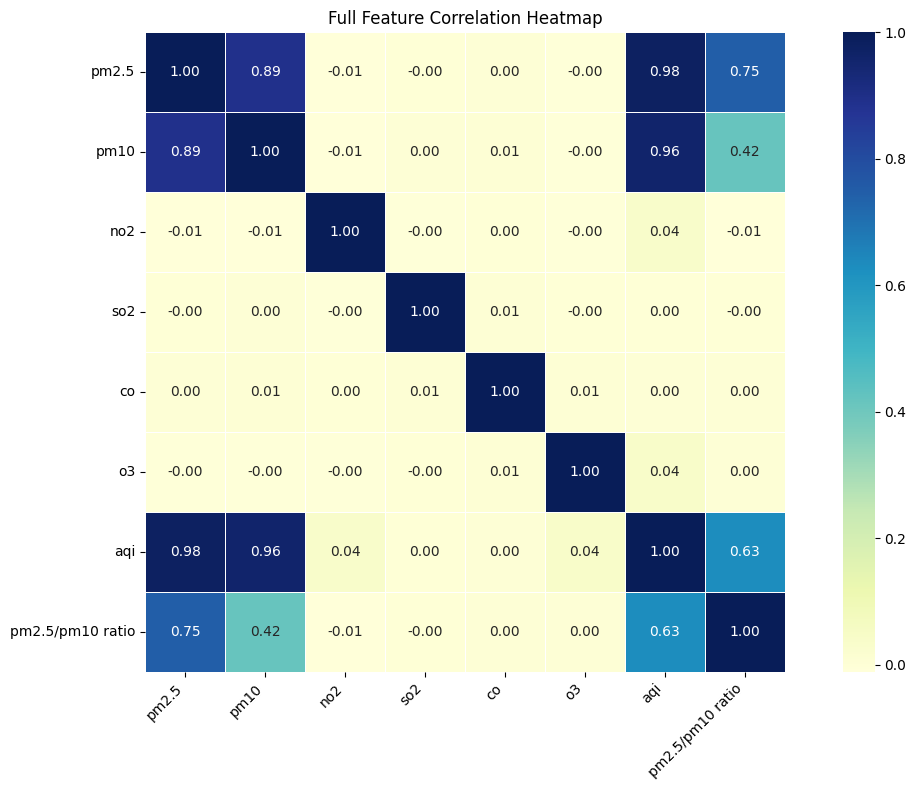

In [18]:
import seaborn as sns
num_df=df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr= num_df.corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu',square = True, fmt='.2f', linewidths=.5)
plt.title("Full Feature Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

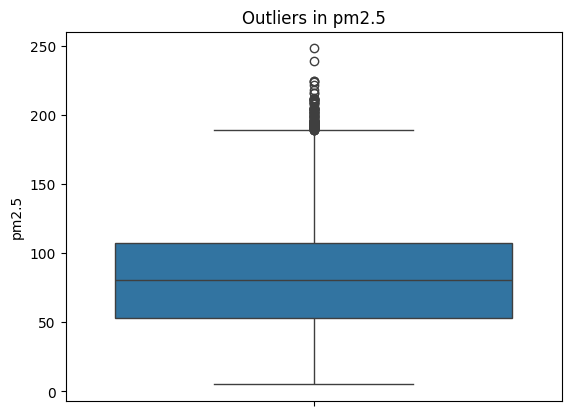

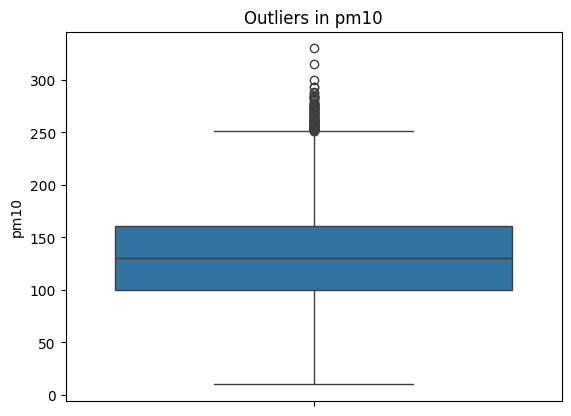

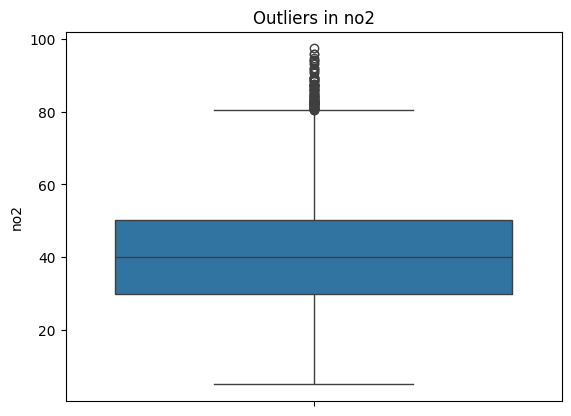

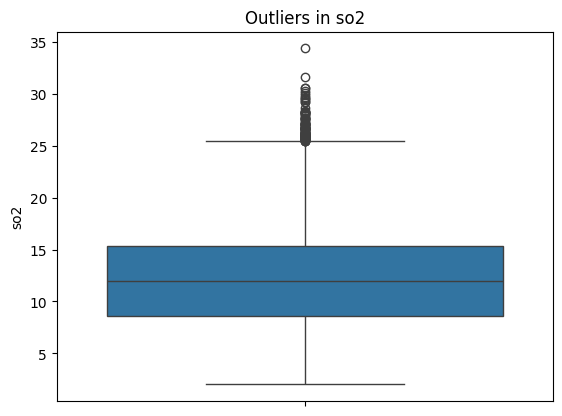

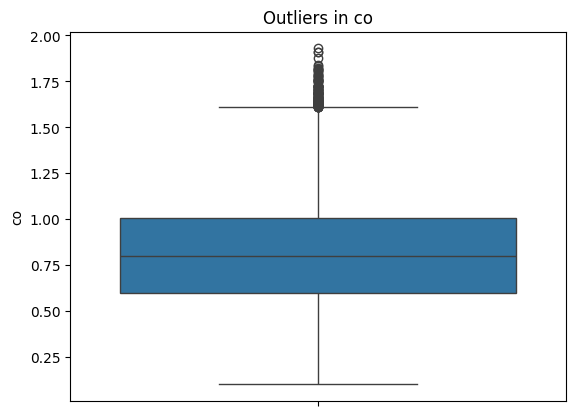

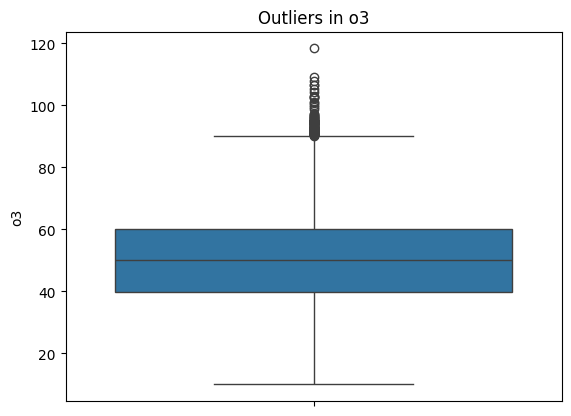

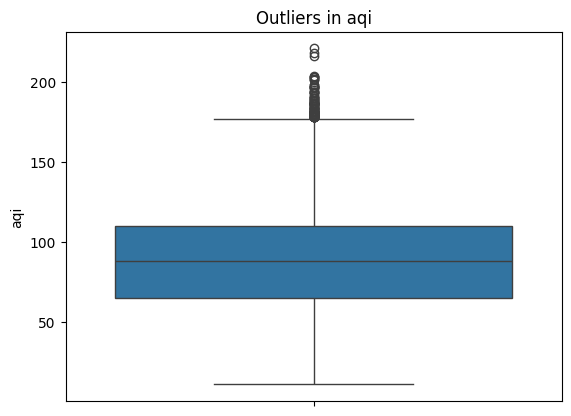

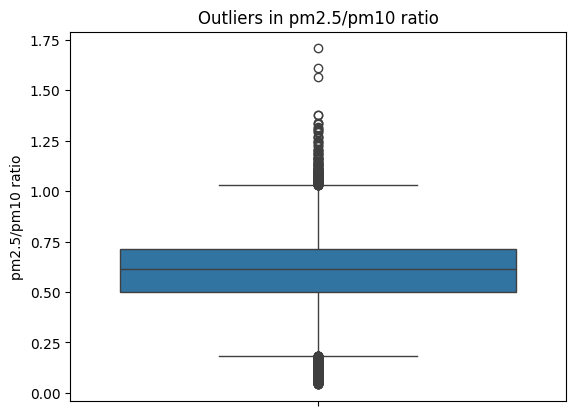

In [19]:
# Outlier Detection
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()

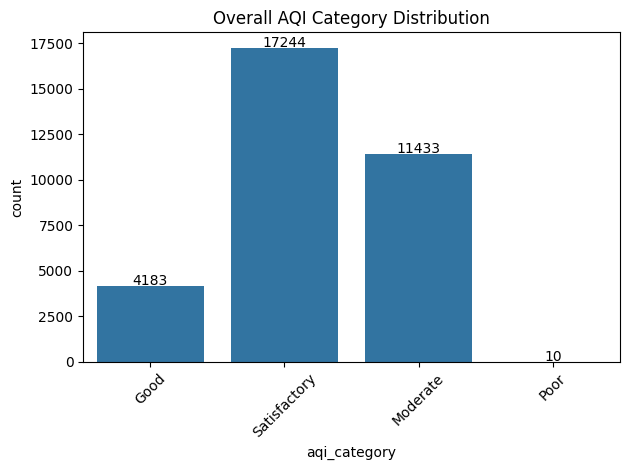

aqi_category
Satisfactory    0.524612
Moderate        0.347825
Good            0.127259
Poor            0.000304
Name: proportion, dtype: float64


In [20]:
# Target Varaible Distribution
#Overall Distribution

plt.figure()
ax = sns.countplot(data=df, x='aqi_category')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height+50), ha='center')

plt.xticks(rotation=45)
plt.title("Overall AQI Category Distribution")
plt.tight_layout()
plt.show()

print(df['aqi_category'].value_counts(normalize=True))

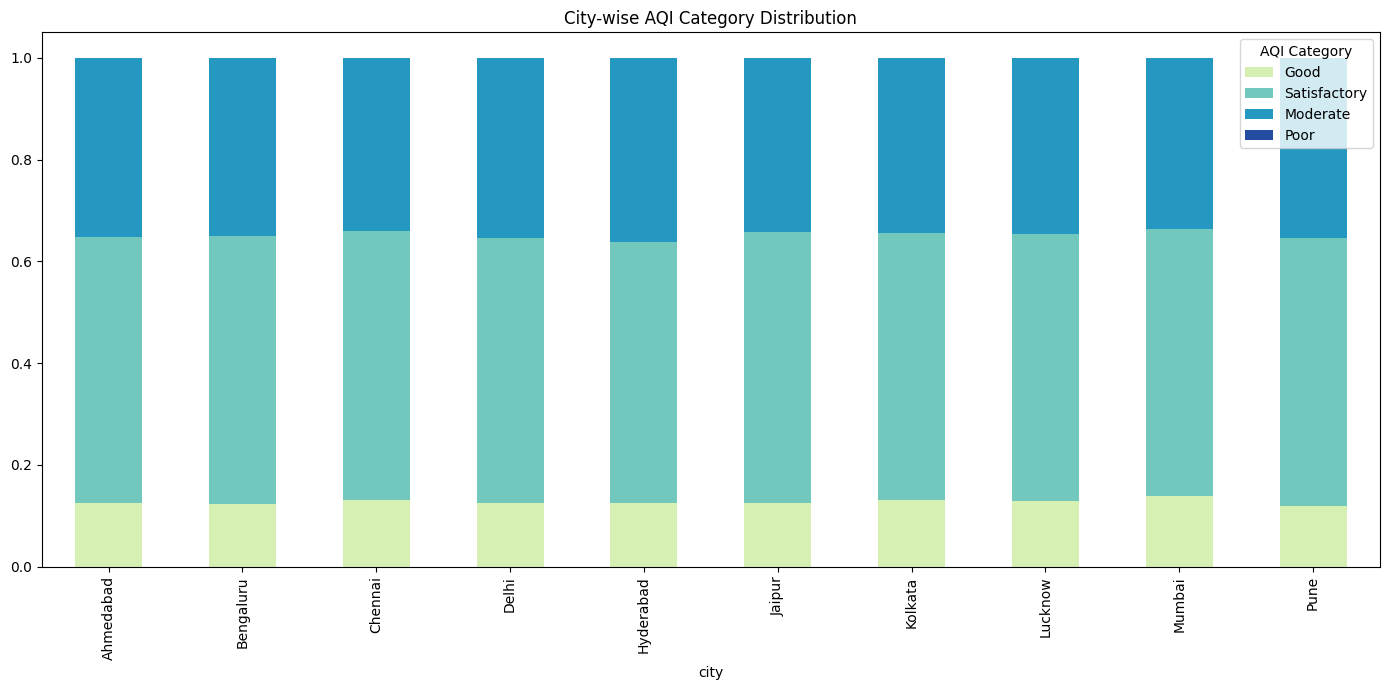

In [21]:
# City-wise AQI Category Distribution

city_dist = pd.crosstab(df['city'], df['aqi_category'], normalize = 'index')
colors = sns.color_palette("YlGnBu", n_colors=len(city_dist.columns))
city_dist.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors, edgecolor= 'none')
plt.xticks(rotation=90)
plt.title("City-wise AQI Category Distribution")
plt.legend(title='AQI Category')
plt.tight_layout()
plt.show()

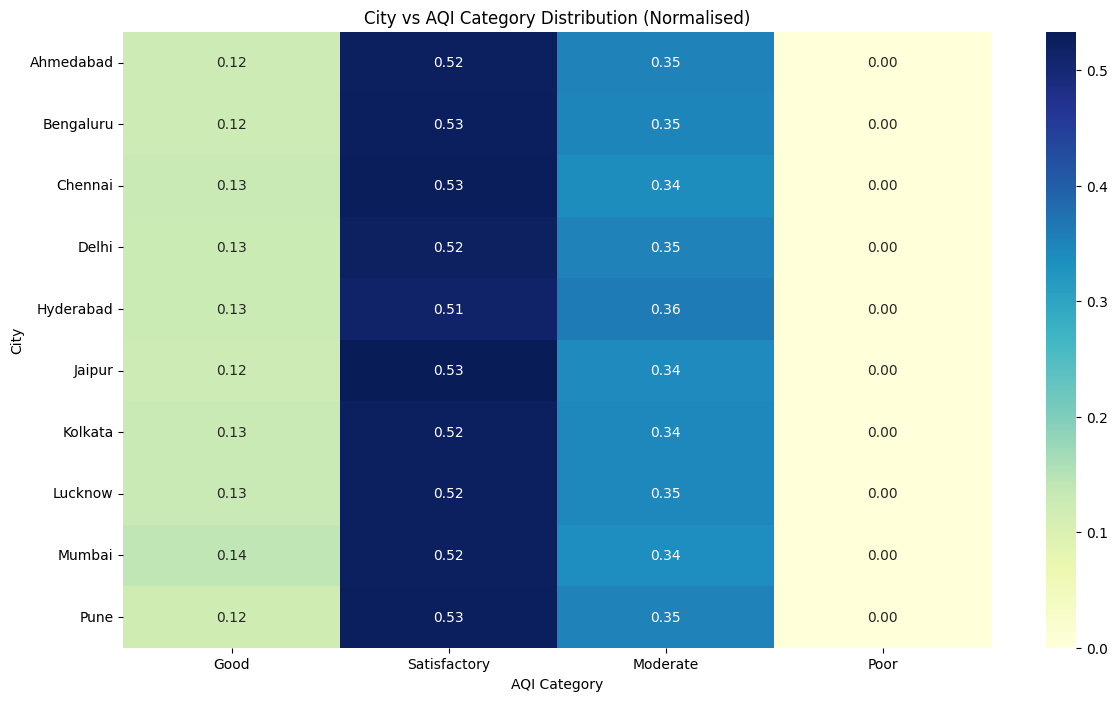

In [22]:
city_cat= pd.crosstab(df['city'], df['aqi_category'], normalize='index')

plt.figure(figsize=(14, 8))
sns.heatmap(city_cat, cmap='YlGnBu', annot=True, fmt='.2f')

plt.title("City vs AQI Category Distribution (Normalised)")
plt.ylabel("City")
plt.xlabel("AQI Category")
plt.show()

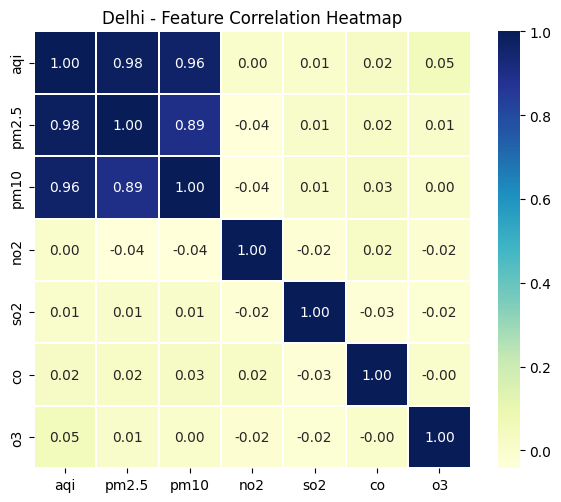

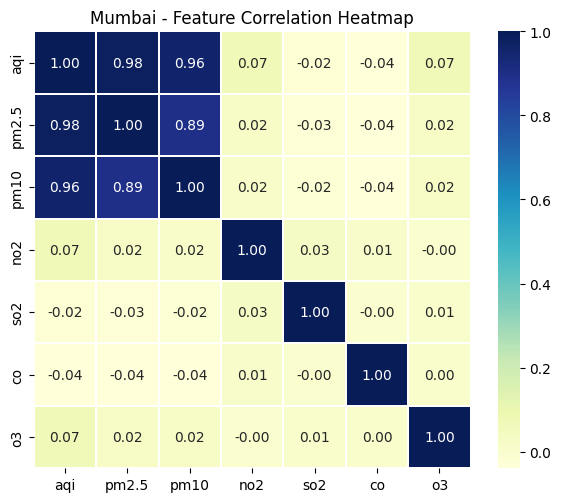

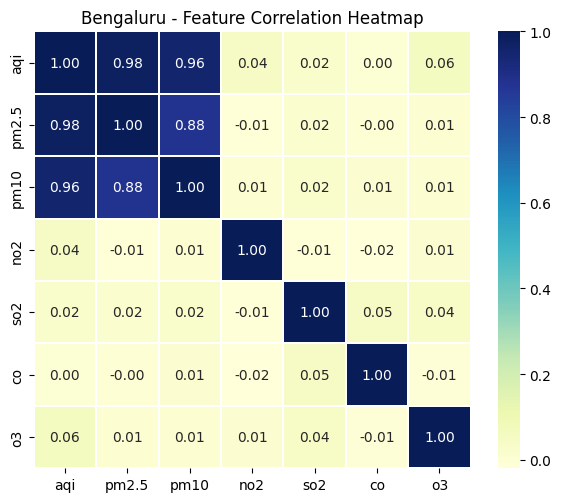

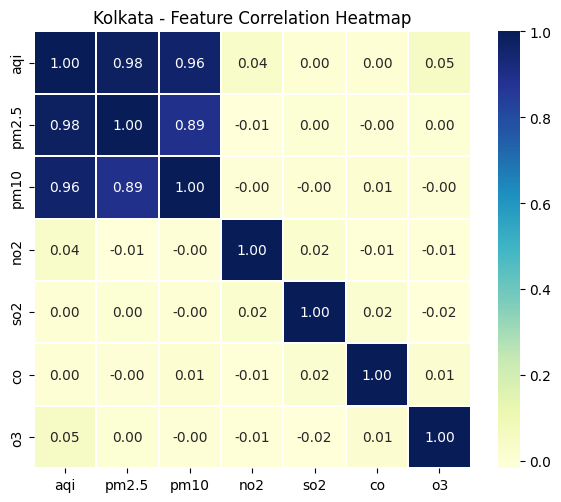

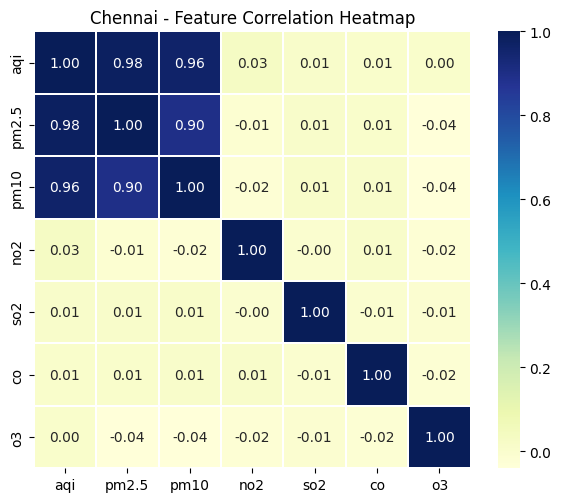

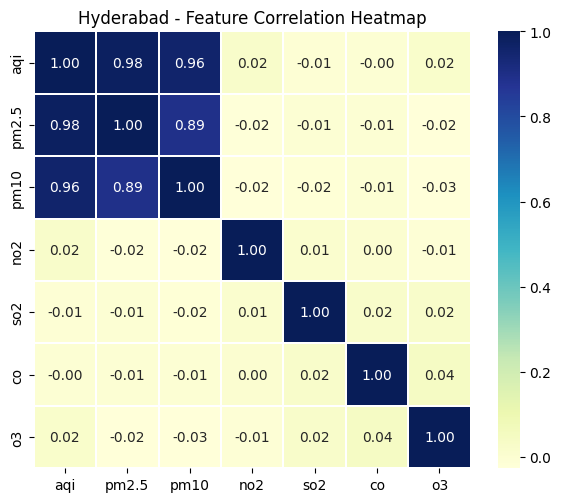

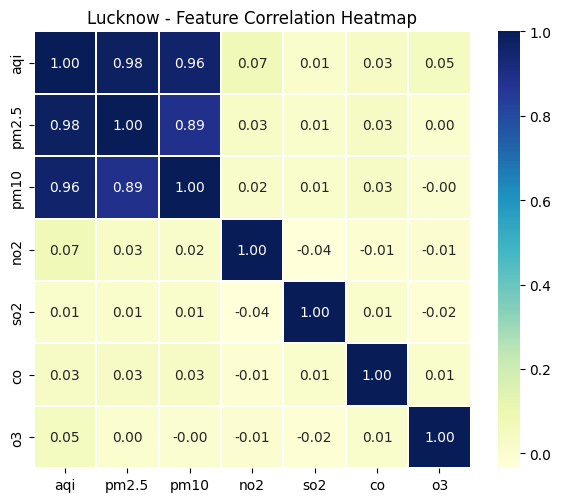

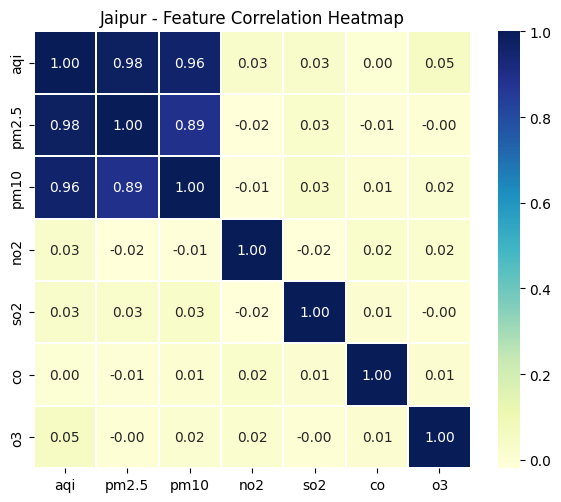

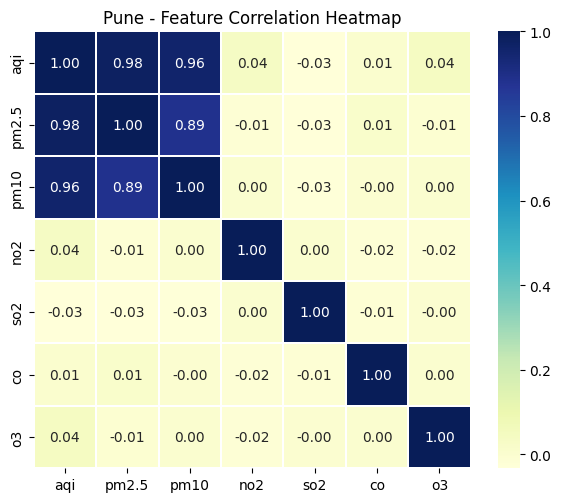

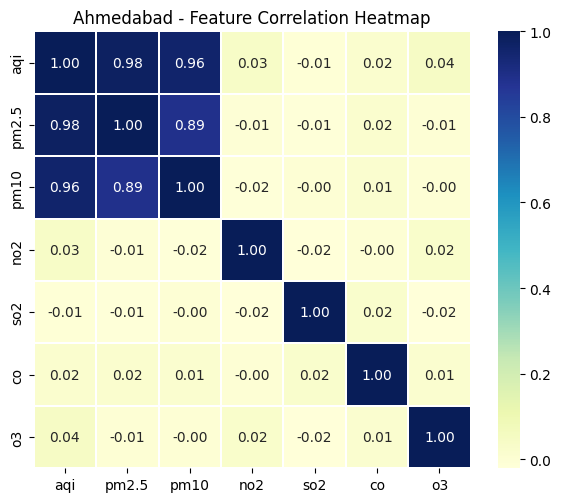

In [23]:
# City-wise Feature Correlation Heatmap
features = ['aqi', 'pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']
features = [f for f in features if f in df.columns]

cities = df['city'].unique()

for city in cities:
    temp = df[df['city'] == city][features]
    if len(temp)<30:
        continue
    corr = temp.corr()
    plt.figure(figsize=(6, 5))

    sns.heatmap(corr, annot = True, fmt = '.2f', cmap = "YlGnBu", square = True, linewidths = 0.3)

    plt.title(f"{city} - Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [24]:
# Date column is date-time
df['date']= pd.to_datetime(df['date'])

In [25]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'
df['season'] = df['date'].dt.month.apply(get_season)

df.to_csv('../data/india_city_aqi_2015_2023-cleaned_dataset.csv', index=False)

print("- File saved as: '../data/india_city_aqi_2015_2023-cleaned_dataset.csv' ")

- File saved as: '../data/india_city_aqi_2015_2023-cleaned_dataset.csv' 


In [26]:
df['season'] = pd.Categorical(df['season'], categories=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'], ordered=True)

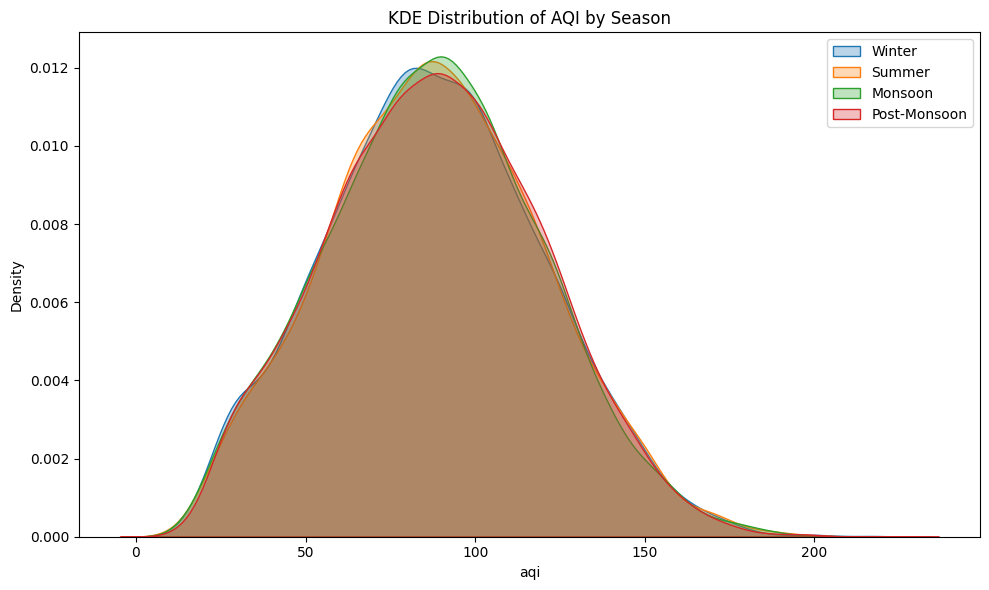

In [27]:
# KDE Distribution of AQI by Season

plt.figure(figsize=(10, 6))

for season in df['season'].unique():
    subset = df[df['season'] == season]
    sns.kdeplot(subset['aqi'], label=season, fill=True, alpha=0.3)
plt.title("KDE Distribution of AQI by Season")
plt.legend(title='Season')
plt.ylabel("Density")

plt.legend()
plt.tight_layout()
plt.show()

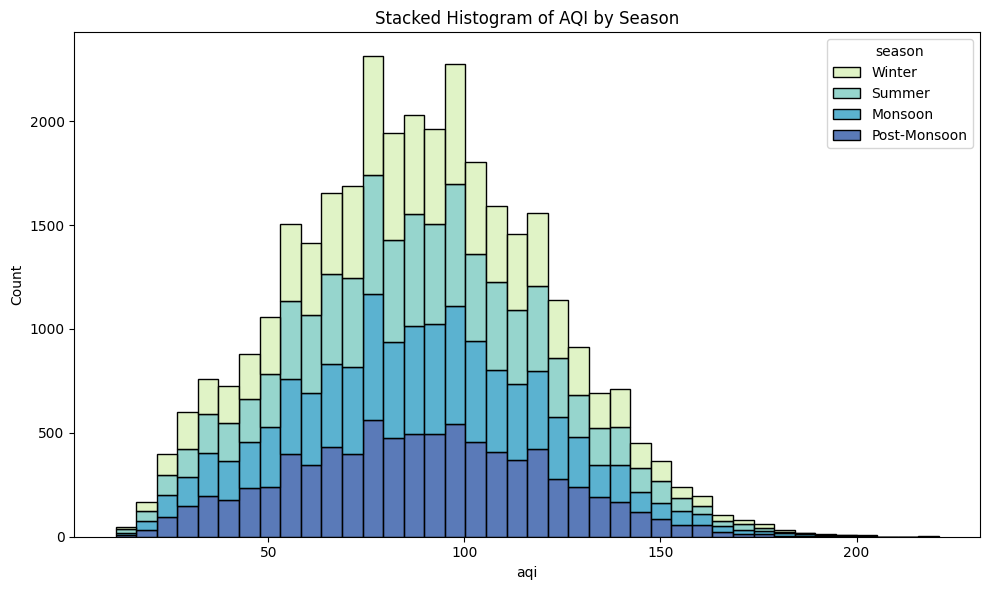

In [28]:
# Stacked Histogram of AQI by Season

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='aqi', hue='season', multiple='stack', bins=40, palette='YlGnBu')
plt.title("Stacked Histogram of AQI by Season")
plt.tight_layout()
plt.show()

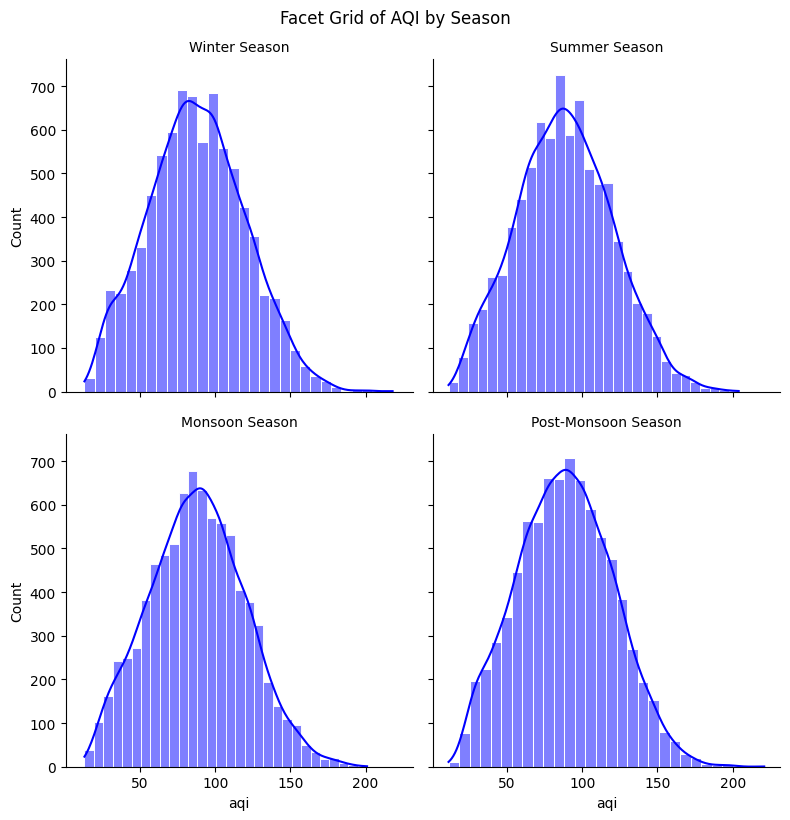

In [29]:
# Facet Grid of AQI by Season

g=sns.FacetGrid(df, col='season', col_wrap=2, height=4)
g.map(sns.histplot, 'aqi', bins=30, kde=True, color='blue', edgecolor='white')
g.set_titles("{col_name} Season")
g.fig.suptitle("Facet Grid of AQI by Season", y=1.02)
plt.show()

In [30]:
print(df['season'].value_counts())

season
Summer          8280
Monsoon         8280
Post-Monsoon    8190
Winter          8120
Name: count, dtype: int64
